5 1000


/share/home2/ebrahimis/project1_3_8/venv/lib/python3.8/site-packages/torch/nn/functional.py:1340: UserWarning: nn.functional.tanh is deprecated. Use torch.tanh instead.
  warnings.warn("nn.functional.tanh is deprecated. Use torch.tanh instead.")
/share/home2/ebrahimis/project1_3_8/oran/oran_enabled_mobility_aware_slicing/radio_calc.py:534: RuntimeWarning: divide by zero encountered in log10
  self.signal_strength_dB[u] = 10 * np.log10(self.signal_strength)
/share/home2/ebrahimis/project1_3_8/oran/oran_enabled_mobility_aware_slicing/radio_calc.py:538: RuntimeWarning: divide by zero encountered in log10
  self.SINR_dB[u] = 10 * np.log10(self.SINR)
/share/home2/ebrahimis/project1_3_8/oran/oran_enabled_mobility_aware_slicing/radio_calc.py:532: RuntimeWarning: divide by zero encountered in log10
  self.interference_dB[u] = 10 * np.log10(I_inter)


Total Handovers  over all timesteps: Episode 0= 1686 HOs, reward= 0.7556782634882521


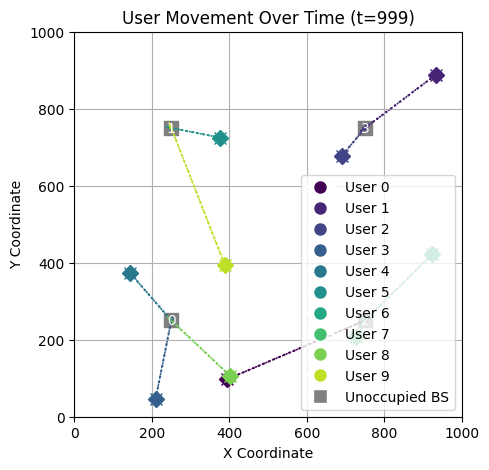

Total Handovers  over all timesteps: Episode 1= 2 HOs, reward= 0.5774130624198571


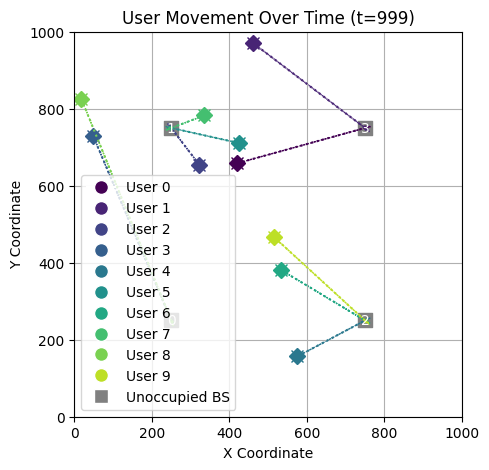

DUPLICATED! Episode: 2, Timestep: 1, Reward: 0.9882026972042017
DUPLICATED! Episode: 2, Timestep: 2, Reward: 0.9883319065907986
DUPLICATED! Episode: 2, Timestep: 3, Reward: 0.9860226558271742
DUPLICATED! Episode: 2, Timestep: 4, Reward: 0.9886113495741278
DUPLICATED! Episode: 2, Timestep: 5, Reward: 0.9877945083913604
DUPLICATED! Episode: 2, Timestep: 6, Reward: 0.9873601805246509
DUPLICATED! Episode: 2, Timestep: 7, Reward: 0.9897713942298152
DUPLICATED! Episode: 2, Timestep: 8, Reward: 0.9884446204933977
DUPLICATED! Episode: 2, Timestep: 9, Reward: 0.9885574810725226
DUPLICATED! Episode: 2, Timestep: 10, Reward: 0.9873634916560089
DUPLICATED! Episode: 2, Timestep: 11, Reward: 0.9890689379294949
DUPLICATED! Episode: 2, Timestep: 12, Reward: 0.988134317487848
DUPLICATED! Episode: 2, Timestep: 13, Reward: 0.9881175098334426
DUPLICATED! Episode: 2, Timestep: 14, Reward: 0.9872947552202691
DUPLICATED! Episode: 2, Timestep: 15, Reward: 0.9876787389656947
DUPLICATED! Episode: 2, Timestep: 1

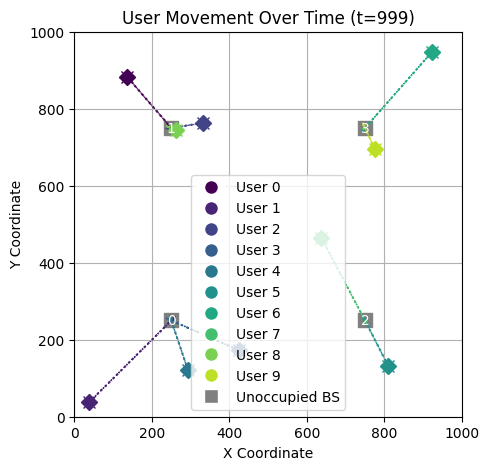

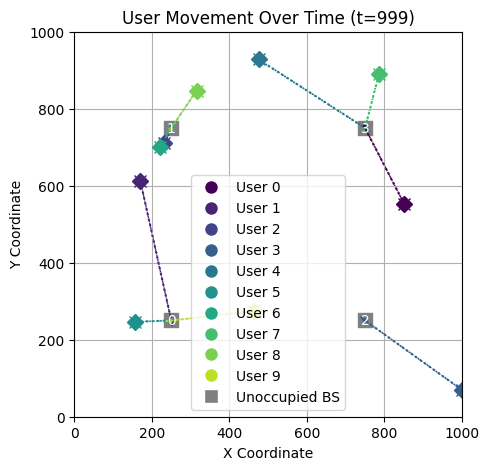

DUPLICATED! Episode: 4, Timestep: 7, Reward: 0.9787461276545963
DUPLICATED! Episode: 4, Timestep: 8, Reward: 0.9816881734297179
DUPLICATED! Episode: 4, Timestep: 9, Reward: 0.9794369839008477
DUPLICATED! Episode: 4, Timestep: 10, Reward: 0.9811575697998095
DUPLICATED! Episode: 4, Timestep: 11, Reward: 0.9792336664957065
DUPLICATED! Episode: 4, Timestep: 12, Reward: 0.9811326591837247
DUPLICATED! Episode: 4, Timestep: 13, Reward: 0.977960482471042
DUPLICATED! Episode: 4, Timestep: 14, Reward: 0.9815515600691678
DUPLICATED! Episode: 4, Timestep: 15, Reward: 0.980374245950034
DUPLICATED! Episode: 4, Timestep: 16, Reward: 0.978683208413195
DUPLICATED! Episode: 4, Timestep: 17, Reward: 0.9773689591405987
DUPLICATED! Episode: 4, Timestep: 18, Reward: 0.9812964372964886
DUPLICATED! Episode: 4, Timestep: 19, Reward: 0.9788589388488067
DUPLICATED! Episode: 4, Timestep: 20, Reward: 0.9776922109819828
DUPLICATED! Episode: 4, Timestep: 21, Reward: 0.9773532980560364
DUPLICATED! Episode: 4, Timeste

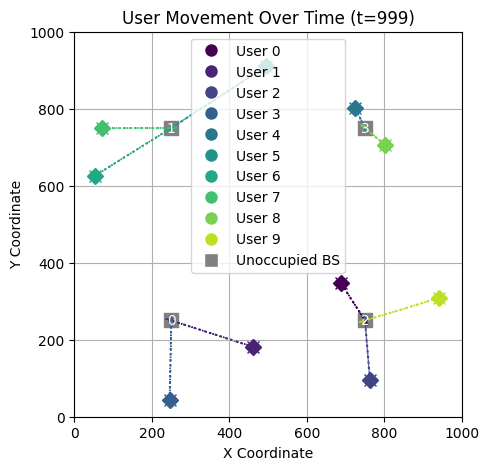

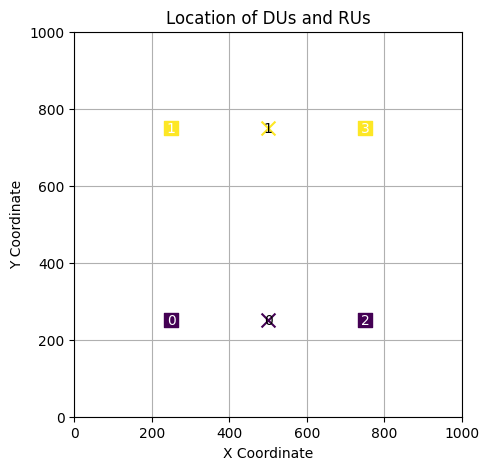

-------------
Runtime Duration:
-------------



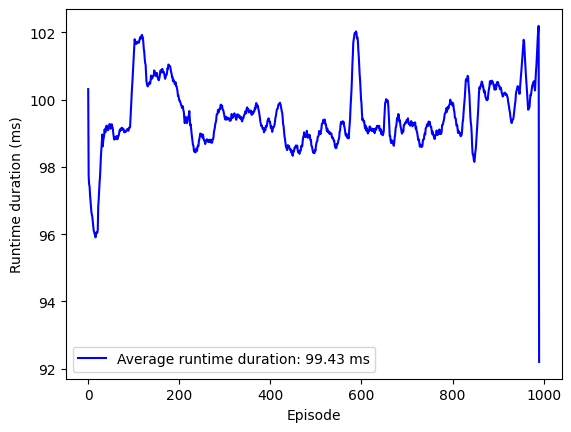

-------------
Avg PRBs used per user for SAC algorithm:
-------------



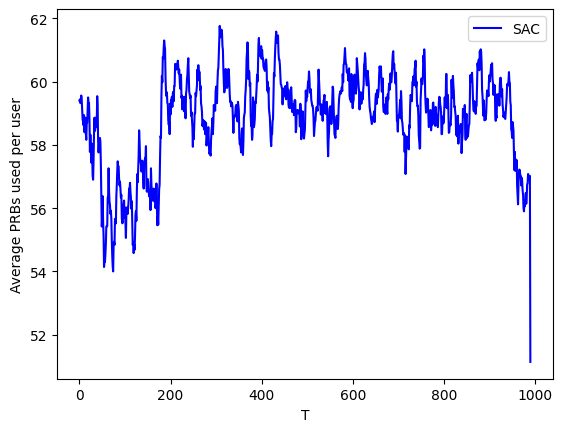

NameError: name 'num_groups' is not defined

In [1]:
%run "main_constraint-based.py"

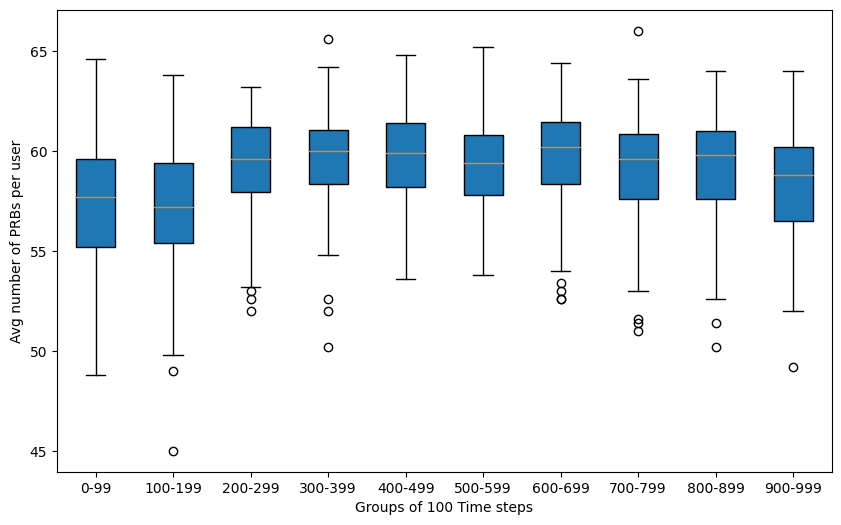

-------------
logarithmic rewards:
-------------



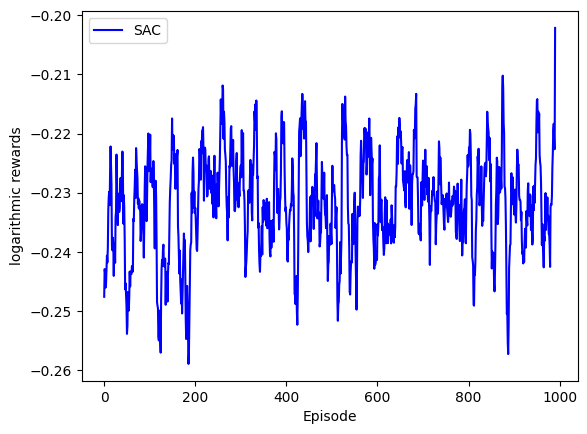

-------------
Mean episodic rewards:
-------------



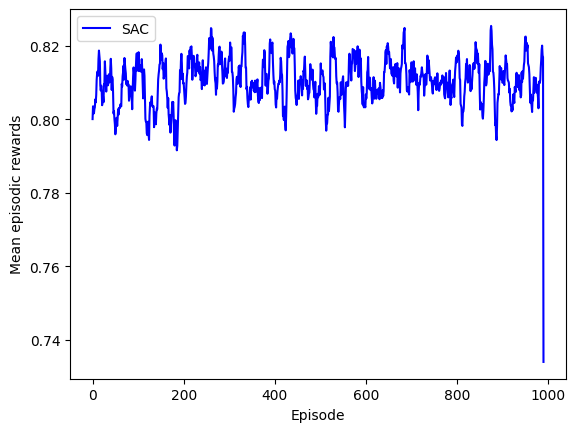

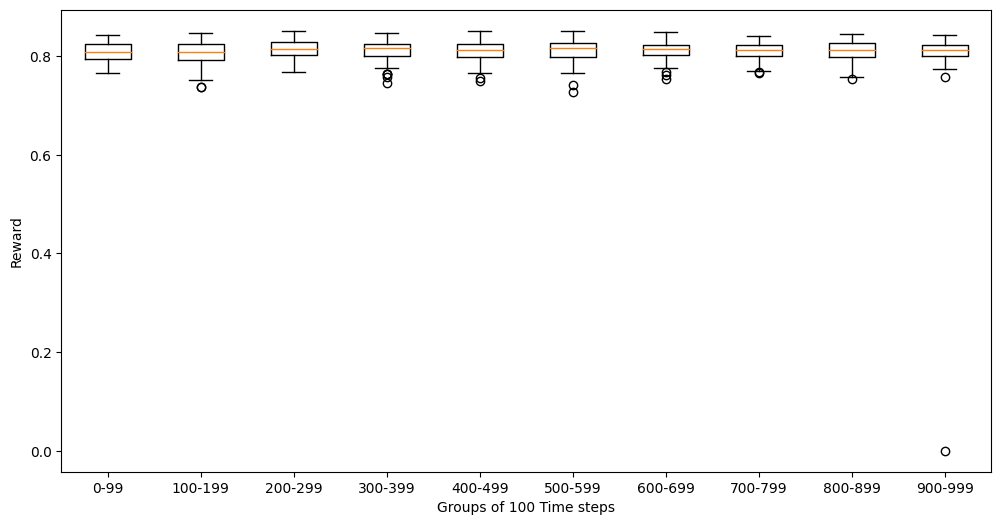

-------------
Constraint Satisfaction:
-------------



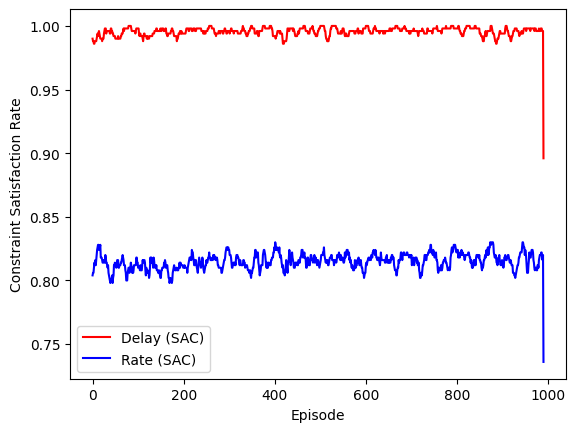

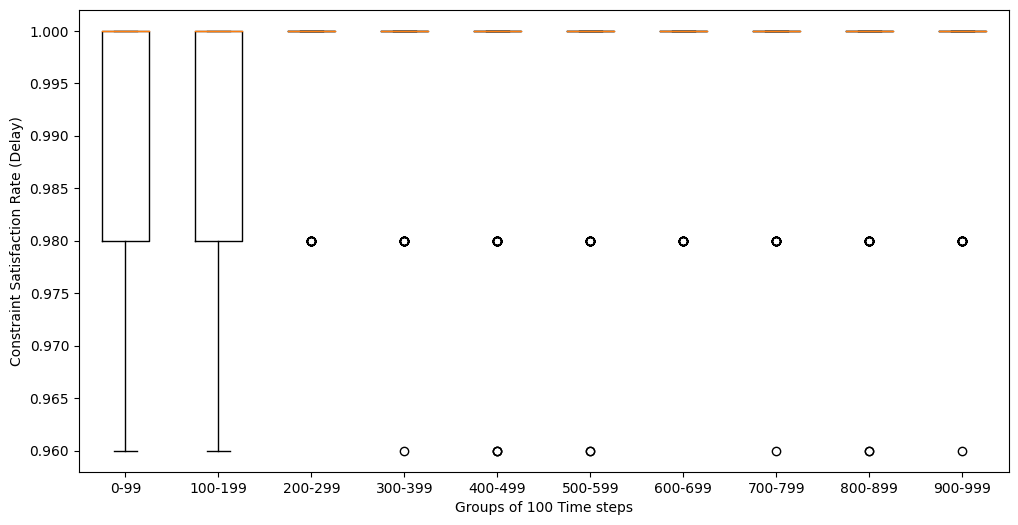

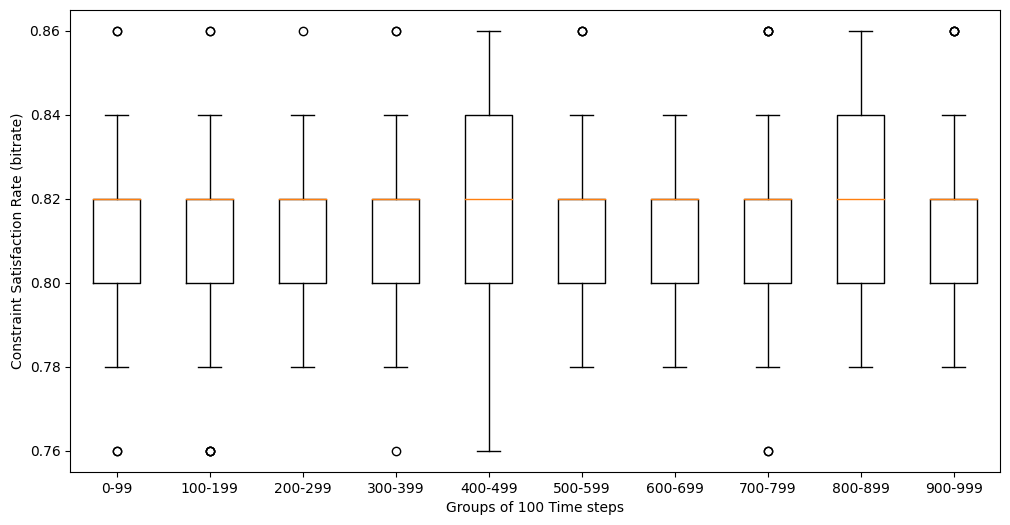

-------------
SSL Metrics:
-------------



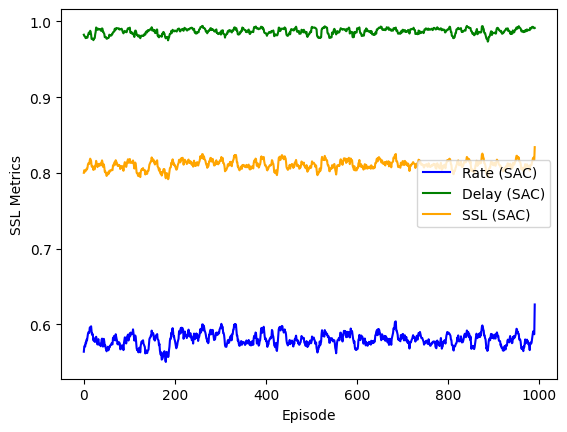

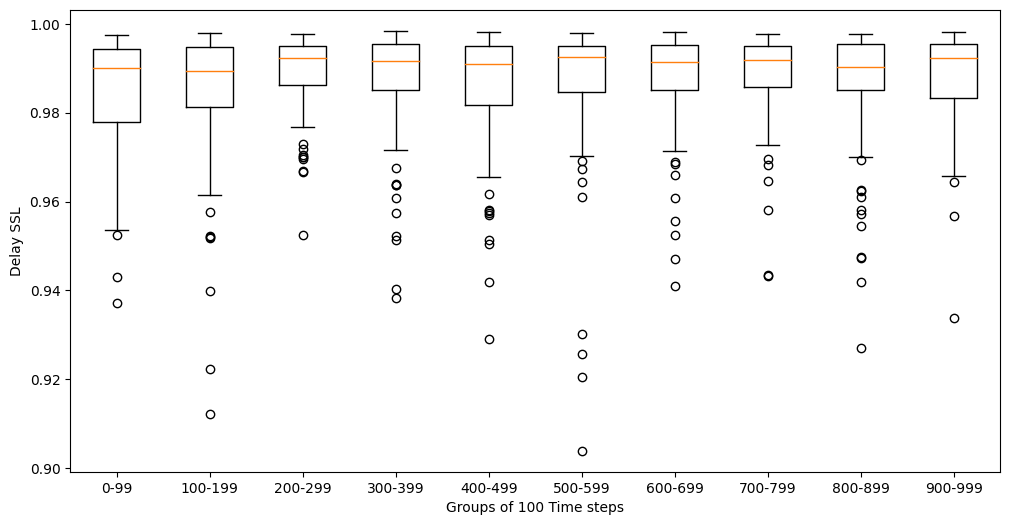

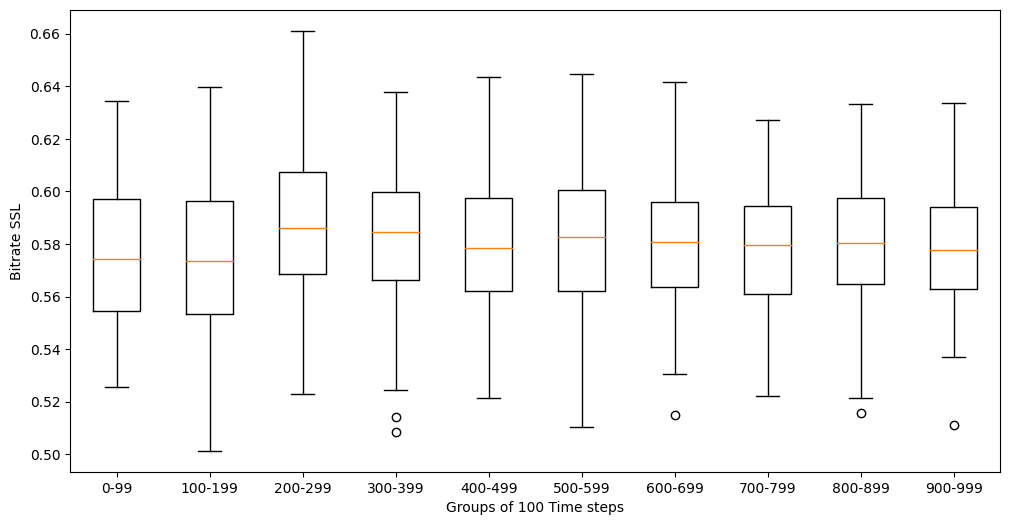

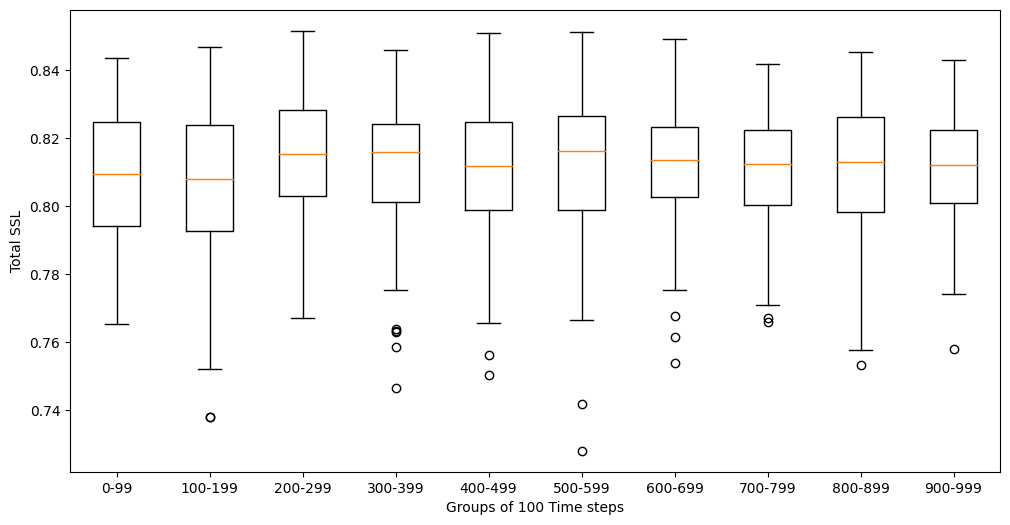

-------------
Comparison of Average E2E Delay (SAC):
-------------



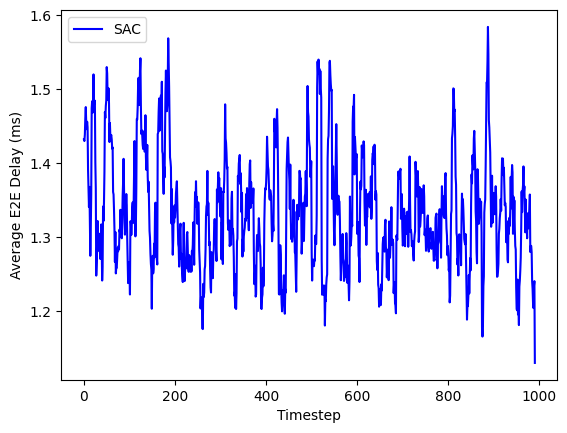

-------------
Average Data Rate (SAC):
-------------



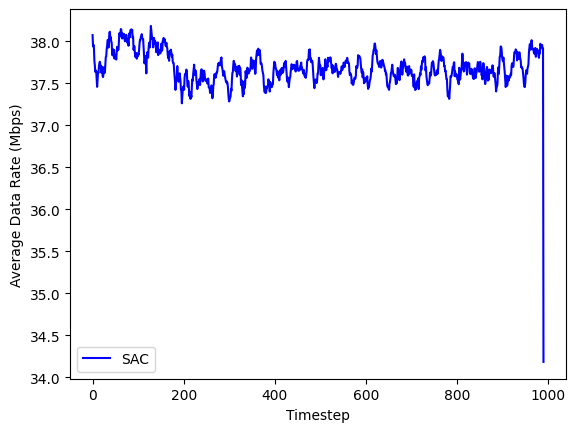

-------------
Average of total allocated power to each user (SAC):
-------------



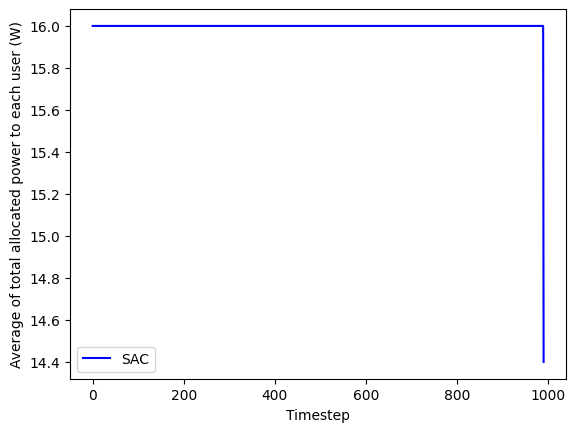

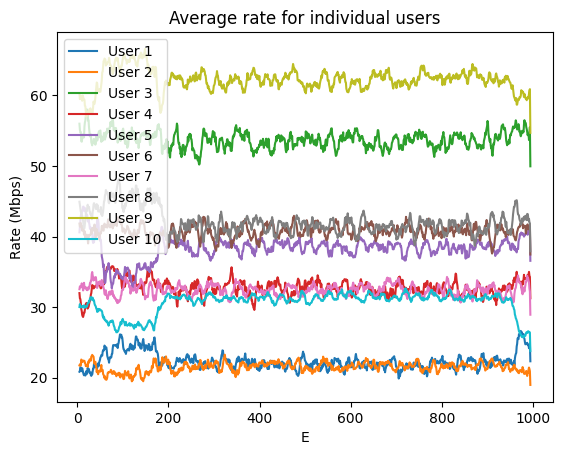

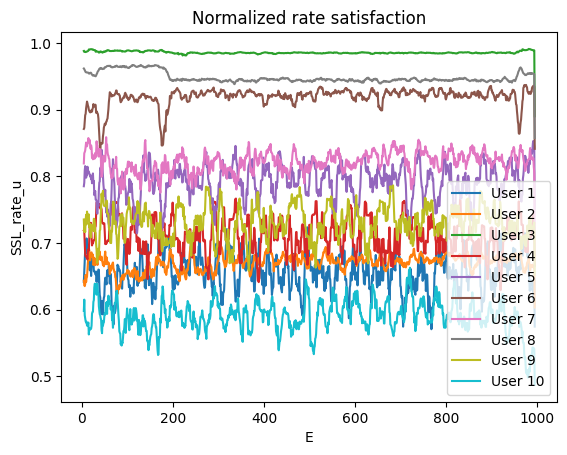

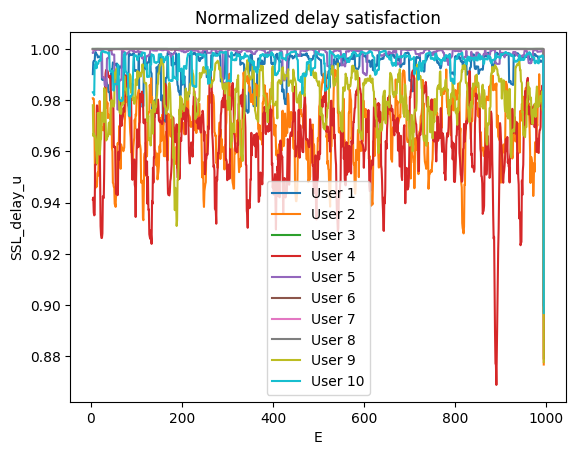

-------------
Sum of handovers :
-------------



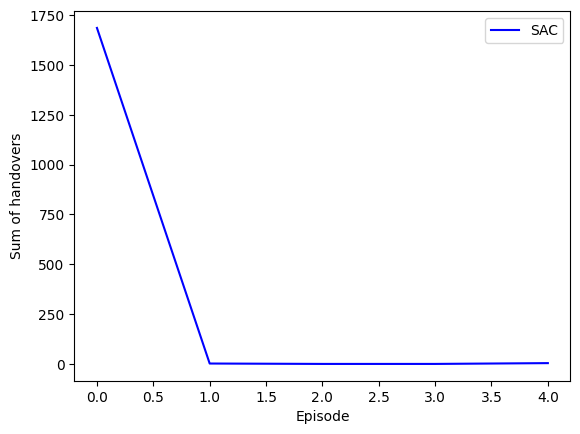

-------------
No. of satisfied delay and rate constraints (Max= 2*U):
-------------



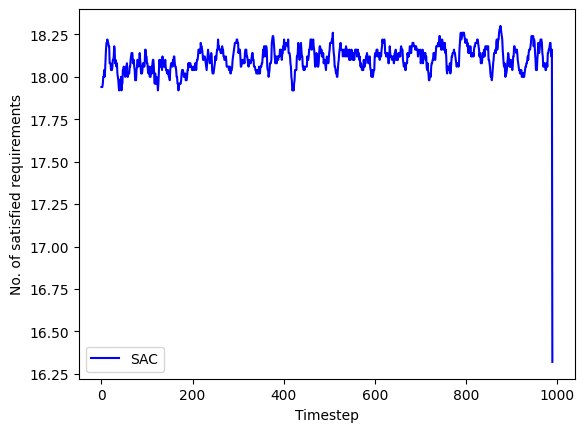

Total time for 1000 timesteps (10 users) in 5 Episdoes (aka iterations or epochs): 8.0 minutes 17.16444730758667 seconds


In [2]:

group_size = T//10
num_groups = 10
avg_prbs_per_user = np.mean(mat_used_prbs_per_user, axis=(1))
temp_prb = avg_prbs_per_user[:,:-1]
avg_prbs_per_user_box = np.average(temp_prb, axis=0)

grouped_data = [avg_prbs_per_user_box[i * group_size:(i + 1) * group_size]for i in range(num_groups)]

# Create a box plot for the grouped rewards

plt.figure(figsize=(10, 6))
plt.boxplot(grouped_data, vert=True, patch_artist=True)
plt.xlabel('Groups of 100 Time steps')
plt.ylabel('Avg number of PRBs per user')
# plt.title('Box Plot of PRB allocations Grouped by 50 Episodes')
plt.xticks(ticks=np.arange(1, num_groups + 1), labels=[f'{i*group_size}-{(i+1)*group_size-1}' for i in range(num_groups)])
plt.show()

# Fairness for PRBs
# Calculate PRB utilization for each user at each time step and for each MC run
# prb_utilization = np.sum(mat_rho, axis=(0, 1))  # Sum over PRBs and BSs

# # Calculate proportional fairness score for each time step
# fairness_scores = np.zeros((E, T))

# for e in range(E):
#     for t in range(T):
#         # Calculate Jain's fairness index for time step t in MC run mc
#         sum_of_prbs = np.sum(prb_utilization[e, :, t])
#         sum_of_squares = np.sum(prb_utilization[e, :, t] ** 2)
#         # Handle potential division by zero or NaN
#         if sum_of_prbs == 0 or np.isnan(sum_of_squares):
#             fairness_scores[e, t] = 0  # Set fairness score to 0
#         else:
#             fairness_scores[e, t] = (sum_of_prbs ** 2) / (BS_NO * sum_of_squares)

# # Average fairness scores over all MC runs
# avg_fairness_scores = np.mean(fairness_scores, axis=1)
# normalized_fairness_scores = (avg_fairness_scores - np.min(avg_fairness_scores)) / (np.max(avg_fairness_scores) - np.min(avg_fairness_scores))


# plot_graph("Jain's fairness index for PRB allocation",
#            [moving_average(normalized_fairness_scores , window_size)],
#            ['SAC'],
#            ['blue'],
#            ['solid'],
#            "Episode",
#            "Mean fairness score")

# %%REWARD%%%%

plot_graph("logarithmic rewards",
           [moving_average(np.average(logarithmic_reward, axis=0), window_size)],
           ['SAC'],
           ['blue'],
           ['solid'],
           "Episode",
           "logarithmic rewards")
#e,t
plot_graph("Mean episodic rewards",
           [moving_average(np.average(mat_reward, axis=0), window_size)],
           ['SAC'],
           ['blue'],
           ['solid'],
           "Episode",
           "Mean episodic rewards")

mat_reward_boxplot = np.average(mat_reward, axis=0)


data = [mat_reward_boxplot[i*group_size:(i+1)*group_size] for i in range(num_groups)]

# Plotting
plt.figure(figsize=(12, 6))
plt.boxplot(data)
plt.xlabel('Groups of 100 Time steps')
plt.ylabel('Reward')
plt.xticks(ticks=range(1, num_groups + 1), labels=[f'{i*group_size}-{(i+1)*group_size-1}' for i in range(num_groups)])
plt.show()


plot_graph("Constraint Satisfaction",
           [moving_average(np.average(mat_satisfied_delay_constraint, axis=0), window_size),
            moving_average(np.average(mat_satisfied_rate_constraint, axis=0), window_size)],
           ['Delay (SAC)',
            'Rate (SAC)'],
           ['red', 'blue'],
           ['solid', 'solid'],
           "Episode",
           "Constraint Satisfaction Rate")


temp_delay = mat_satisfied_delay_constraint[:, :-1]
mat_satisfied_delay_constraint_box = np.average(temp_delay, axis=0)
data = [mat_satisfied_delay_constraint_box[i*group_size:(i+1)*group_size] for i in range(num_groups)]

# Plotting
plt.figure(figsize=(12, 6))
plt.boxplot(data)
plt.xlabel('Groups of 100 Time steps')
plt.ylabel('Constraint Satisfaction Rate (Delay)')
plt.xticks(ticks=range(1, num_groups + 1), labels=[f'{i*group_size}-{(i+1)*group_size-1}' for i in range(num_groups)])
plt.show()


temp_rate =mat_satisfied_rate_constraint[:, :-1]
mat_satisfied_rate_constraint_box = np.average(temp_rate, axis=0)
data = [mat_satisfied_rate_constraint_box[i*group_size:(i+1)*group_size] for i in range(num_groups)]

# Plotting
plt.figure(figsize=(12, 6))
plt.boxplot(data)
plt.xlabel('Groups of 100 Time steps')
plt.ylabel('Constraint Satisfaction Rate (bitrate)')
plt.xticks(ticks=range(1, num_groups + 1), labels=[f'{i*group_size}-{(i+1)*group_size-1}' for i in range(num_groups)])
plt.show()


# %%%%%SSL%%%%%%
plot_graph("SSL Metrics",
           [moving_average(np.average(mat_ssl_rate, axis=0), window_size),
            moving_average(np.average(mat_ssl_delay, axis=0), window_size),
            moving_average(np.average(mat_ssl, axis=0), window_size)],
           ['Rate (SAC)',
            'Delay (SAC)',
            'SSL (SAC)'],
           ['blue', 'green', 'orange'],
           ['solid', 'solid', 'solid'],
           "Episode",
           "SSL Metrics")

temp_delay = mat_ssl_delay[:, :-1]
mat_ssl_delay_box = np.average(temp_delay, axis=0)
data = [mat_ssl_delay_box[i*group_size:(i+1)*group_size] for i in range(num_groups)]

# Plotting
plt.figure(figsize=(12, 6))
plt.boxplot(data)
plt.xlabel('Groups of 100 Time steps')
plt.ylabel('Delay SSL')
plt.xticks(ticks=range(1, num_groups + 1), labels=[f'{i*group_size}-{(i+1)*group_size-1}' for i in range(num_groups)])
plt.show()


temp_rate =mat_ssl_rate[:, :-1]
mat_ssl_rate_box = np.average(temp_rate, axis=0)
data = [mat_ssl_rate_box[i*group_size:(i+1)*group_size] for i in range(num_groups)]

# Plotting
plt.figure(figsize=(12, 6))
plt.boxplot(data)
plt.xlabel('Groups of 100 Time steps')
plt.ylabel('Bitrate SSL')
plt.xticks(ticks=range(1, num_groups + 1), labels=[f'{i*group_size}-{(i+1)*group_size-1}' for i in range(num_groups)])
plt.show()



temp_ssl =mat_ssl[:, :-1]
mat_ssl_box = np.average(temp_ssl, axis=0)
data = [mat_ssl_box[i*group_size:(i+1)*group_size] for i in range(num_groups)]

# Plotting
plt.figure(figsize=(12, 6))
plt.boxplot(data)
plt.xlabel('Groups of 100 Time steps')
plt.ylabel('Total SSL')
plt.xticks(ticks=range(1, num_groups + 1), labels=[f'{i*group_size}-{(i+1)*group_size-1}' for i in range(num_groups)])
plt.show()

# %%%%%Delay%%%%%%
# Calculate mean delay over users for SAC
mean_delay_sac = np.mean(np.mean(monte_mat_delay_tot, axis=1), axis=0)
# Plot the comparison graph
plot_graph("Comparison of Average E2E Delay (SAC)",
           [moving_average(mean_delay_sac , window_size)],
           ['SAC'],
           ['blue'],
           ['solid'],
           "Timestep",
           "Average E2E Delay (ms)")

#####################
mean_rate_sac = np.mean(np.mean(shannon, axis=1), axis=0)
# mean_rate_sac_smoothed = moving_average(mean_rate_sac, window_size)
plot_graph("Average Data Rate (SAC)",
           [moving_average(mean_rate_sac , window_size)],
           ['SAC'],
           ['blue'],
           ['solid'],
           "Timestep",
           "Average Data Rate (Mbps)")

#####################
mean_power_sac = np.mean(np.mean(mat_sum_power, axis=1), axis=0)
# mean_power_sac_smoothed = moving_average(mean_power_sac, window_size)
plot_graph("Average of total allocated power to each user (SAC)",
           [moving_average(mean_power_sac , window_size)],
           ['SAC'],
           ['blue'],
           ['solid'],
           "Timestep",
           "Average of total allocated power to each user (W)")

###
average_rate = np.mean(shannon, axis=0)

for user_idx in range(USER_NO):
    plt.plot(moving_average(range(T), window_size), moving_average(average_rate[user_idx,:], window_size), label=f'User {user_idx+1}')
plt.xlabel('E')
plt.ylabel('Rate (Mbps)')
plt.title('Average rate for individual users')
plt.legend()
plt.show()

###
average_rate_ssl_u = np.mean(mat_fittingness_u_rate, axis=0)

for user_idx in range(USER_NO):
    plt.plot(moving_average(range(T), window_size), moving_average(average_rate_ssl_u[user_idx,:], window_size), label=f'User {user_idx+1}')
plt.xlabel('E')
plt.ylabel('SSL_rate_u')
plt.title('Normalized rate satisfaction')
plt.legend()
plt.show()

###
average_delay_ssl_u = np.mean(mat_fittingness_u_delay, axis=0)

for user_idx in range(USER_NO):
    plt.plot(moving_average(range(T), window_size), moving_average(average_delay_ssl_u[user_idx,:], window_size), label=f'User {user_idx+1}')
plt.xlabel('E')
plt.ylabel('SSL_delay_u')
plt.title('Normalized delay satisfaction')
plt.legend()
plt.show()
###
plot_graph("Sum of handovers ",
           [moving_average(np.sum(mat_count_handovers, axis=1) , 1)],
           ['SAC'],
           ['blue'],
           ['solid'],
           "Episode",
           "Sum of handovers")

####
plot_graph("No. of satisfied delay and rate constraints (Max= 2*U)",
           [moving_average(np.average(mat_no_of_satisfied_delay_and_rate_constraint, axis=0), window_size)],
           ['SAC'],
           ['blue'],
           ['solid'],
           "Timestep",
           "No. of satisfied requirements")
###

print(style.UNDERLINE + "Total time for {} timesteps ({} users) in {} Episdoes (aka iterations or epochs): {}".format(T, USER_NO, E, convert_seconds(np.sum(mat_episode_runtime))))



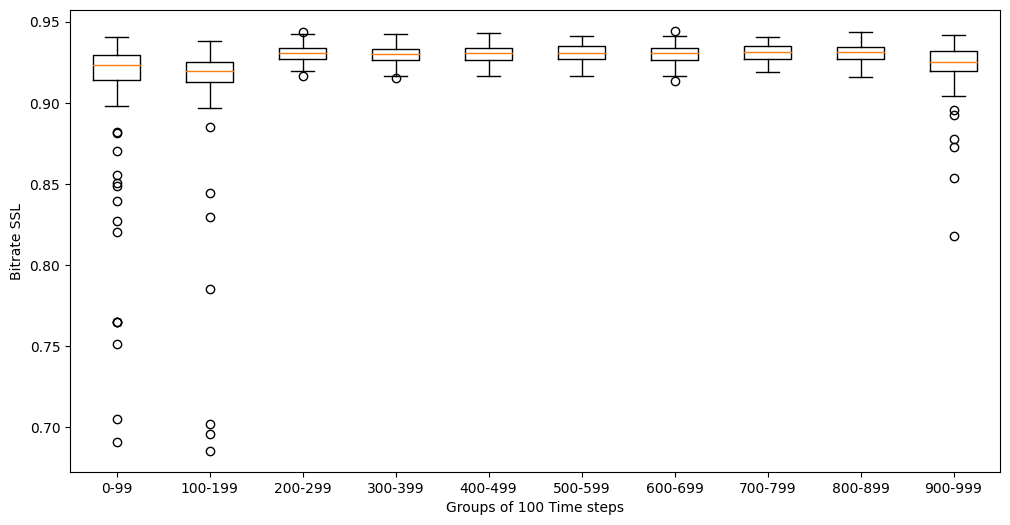

In [8]:

temp_rate =mat_ssl_rate[:, :-1]
mat_ssl_rate_box = temp_rate[4,:]
data = [mat_ssl_rate_box[i*group_size:(i+1)*group_size] for i in range(num_groups)]

# Plotting
plt.figure(figsize=(12, 6))
plt.boxplot(data)
plt.xlabel('Groups of 100 Time steps')
plt.ylabel('Bitrate SSL')
plt.xticks(ticks=range(1, num_groups + 1), labels=[f'{i*group_size}-{(i+1)*group_size-1}' for i in range(num_groups)])
plt.show()


In [ ]:
# config.yaml lstm
# config.yaml 
USER_NO: 10 #10 #20 # 4
BW: 180000  # %  180 kHz  (to be updated after consulting with Faouzi)
PRB_NO: 150 #  (to be updated after consulting with Faouzi)
SIGMA_NOISE: 10**(-17.4) #3.981e-18 # # = -174 dBm <tnsm23nouruzi> #
ETA_AREA: 3 # for rural areas according to TS 38.215 (Used in the Rayleigh/Distance formula for calculating data rate (Shannon)); equal to 3 for rural; 4 for urban areas # check also 38.913 for mobility scenarios and classes
X_LIM: 1000
Y_LIM: 1000
#CU_NO: 1 # only 1 CU is envisioned. It is co-located with the Near-RT RIC
DU_NO: 2 # all connected to the CU
RU_PER_DU_NO: 2 # Each DU has 4 RUs; Total number of RUs = 4*2 = 8
#BS_NO: 20 # should be equal to RU_PER_DU_NO*DU_NO # static for now; Location.bs_location() --- now it is bound to 4 BSs. Can be changed later
FH_BW_CAPACITY: 5000 # 100 Mbps in twc23kavehmadani# Mbps (5 Gbps) (link between RU and its DU) #
E2_BW_CAPACITY: 100000 # 5 Gbps in twc23kavehmadani #Mbps (100 Gbps) (link between DU and Near-RT RIC (equal to F1, which is between DU and CU))
#VM_NO: 9 # 6
#VNF_NO: 5 # 5
#NODE_NO: 12
SLICE_NO: 3 #5 # number of slice types ; will be indexed from 0 to (SLICE_NO - 1)
MAX_POWER: 40 # in watts ; equals to 46 dBm <tvt23choi> # 12 # (to be updated after consulting with Faouzi) # 46 dBm in tvt23choi = 40 watts (Much higher than normal papers)
OMEGA_1: 0.3 # to use in SSL weighting (for data rate term)
VELOCITY: 0 #0 #-1 means random #35 # m/s [5,20,35,50] #             = self.V ##################################################
CONST_D_MAX: 20 # -1 # 20 #-1 # ms
CONST_R_MIN: 10 # -1 # 5 #-1 # Mbps  
#ISOLATION_ORDER: -1
PACKET_SIZE: 0.012 # -1 # 0.012 # based on 1500 bytes for eMBB # in mbits # -1 # twc23kavehmadani: 1 KB for URLLC and 125 KB for eMBB
#PACKET_NO: 830  # 500 # -1 # packet generation rate per second # 0.012*500 = 6 Mbps # 0.012*830 = 9.96 Mbps
RAYLEIGH_SCALE: 1 # sigma in Rayleigh formula
#Episodes (T) and Number of monte-carlo runs:#
E: 5 #1000# episodes/epochs for learning (the loop before T loop (replaces MC loop))
T: 1000 #100# 14000 # 1000  # Number of timeslots
#MC: 3  # Number of Monte-carlo runs
#Hyperparameters for the DRL algorithm
ALPHA_ACT: 0.00001 #01 # 0.00001 # 0.00001 #0.000001 # actor's learning rate
BETA_ACT: 0.00005 # 0.00005 # 0.00005 # 0.00005 # 0.000005 # Critic's learning rate
VAR: 1
DECAY_VAR: 0.999 #95 #95 # .995 # can determine the ratio of exploration to exploitation
PSI: 0.5 # for putting two last actions in states
XI: 3 # shaping parameter for SSL^B_u and SSL^D_u
IOTA: 0.1 # regularization parameter that controls the penalty for low satisfaction levels